# Градиентный спуск (Gradient Descent) — кратко

## Идея

Универсальный алгоритм оптимизации: постепенно подкручиваем параметры θ, чтобы минимизировать функцию ошибки (cost function).

**Аналогия из книги**: ты в тумане в горах, видишь только наклон земли под ногами. Стратегия — идти в сторону самого крутого спуска. Как только уклон = 0, ты в низшей точке (минимуме).

```
Cost
 |●
 | ●
 |  ●●
 |    ●●●
 |       ●●●●
 |___________●●●______________
 старт                минимум      θ
```

## Как это работает на практике

1. **Random initialization** — θ заполняется случайными значениями (старт в случайной точке).
2. Дальше — маленькие шаги, каждый пытается уменьшить cost function (например MSE).
3. Размер шага пропорционален крутизне склона → шаги сами уменьшаются по мере приближения к минимуму.
4. Повторяем, пока не сойдётся (converge) в минимуме.

Скорость шага регулируется гиперпараметром **learning rate**.

---

## Три сценария learning rate

### 1. Слишком маленький — сходится долго
```
●
 ●
  ●
   ●
    ●●●●●●●●●●●●●● (мелкие шаги, ползёт вечно)
```
Алгоритму нужно очень много итераций → долго по времени.

### 2. Слишком большой — расходится (diverge)
```
      ↗ ●
   ● ↙  ↑
    ↘   |
     ●→ прыгает туда-сюда, значения растут
```
Шаг "перепрыгивает" через дно долины на другую сторону, иногда даже выше исходной точки. В худшем случае значения растут всё больше — алгоритм не находит решение вообще.

### 3. Хороший learning rate
```
●
 ●
  ●
   ●●
     ●●●●● (шаги плавно уменьшаются к минимуму)
```

---

## Проблемы рельефа (не все cost function — гладкая чаша)

```
Cost
|\                                    /
| \        ⌒                        /
|  \      /  \                     /
|   \    /    \                  /
|    ●●●●      \________________/
|  Local min          Plateau (плато)
|                Global min
```

- **Local minimum** (локальный минимум) — если старт слева, алгоритм застрянет тут, хотя это не лучшее решение.
- **Global minimum** (глобальный минимум) — настоящее лучшее решение.
- **Plateau** (плато) — плоский участок, где градиент почти 0 → шаги крошечные, движение очень долгое. Если остановиться рано — до глобального минимума не дойти вообще.

---

## Хорошая новость про линейную регрессию

MSE для линейной регрессии — **выпуклая функция (convex)**:
- нет локальных минимумов — только один глобальный
- никаких резких скачков наклона

→ Градиентный спуск **гарантированно** подберётся сколь угодно близко к глобальному минимуму (если ждать достаточно долго и learning rate не слишком велик).

---

## Важность масштаба признаков (feature scaling)

```
Признаки одного масштаба:        Признаки разного масштаба:
   θ2                               θ2
   |  ⬮ (круглая чаша)              |  ▭▭▭ (вытянутая чаша)
   |   ↘                            |  ↘
   |    ↘                           |   →→→→ (сначала вбок,
   |     ● мин.                     |         потом долгий путь
   |________ θ1                     |________●мин.___ θ1
   прямой путь к минимуму           окольный, долгий путь
```

- Слева (одинаковый масштаб) — путь к минимуму почти прямой, сходится быстро.
- Справа (разный масштаб, например x1 намного меньше x2) — путь сначала идёт почти перпендикулярно направлению к минимуму, потом долго "ползёт" по почти плоской долине.

**⚠️ Правило**: перед градиентным спуском признаки нужно приводить к одному масштабу (например через `StandardScaler` из sklearn) — иначе сходимость займёт намного больше времени.

---

## Философский вывод

Обучение модели = поиск такой комбинации параметров θ, которая минимизирует cost function — это **поиск в пространстве параметров модели**.

- Чем больше параметров → тем больше измерений (dimensions) в этом пространстве → тем сложнее искать.
- Аналогия из книги: искать иголку в стоге сена в 300 измерениях намного сложнее, чем в 3.
- Но для линейной регрессии cost function выпуклая — значит "иголка" всегда просто лежит на дне чаши, и найти её несложно.

In [ ]:
# Batch Gradient

# Batch Gradient Descent — разбор с нуля

## Проблема

У модели обычно много параметров (`θ₀, θ₁, ..., θₙ`), не один. Чтобы двигаться к минимуму, нужно понять: если чуть-чуть изменить **один конкретный** `θⱼ`, как изменится cost function (ошибка)?

Это называется **частная производная (partial derivative)** — "частная", потому что смотрим на изменение только по одной переменной, остальные "замораживаем".

Аналогия из книги: ты в горах, спрашиваешь "какой наклон, если идти на восток?", потом отдельно "какой наклон, если идти на север?" — и так для каждого направления.

---

## Уравнение 4-5. Частная производная cost function

$$
\frac{\partial}{\partial \theta_j} \text{MSE}(\boldsymbol{\theta}) = \frac{2}{m} \sum_{i=1}^{m} \left( \boldsymbol{\theta}^\top \mathbf{x}^{(i)} - y^{(i)} \right) x_j^{(i)}
$$

### Как это читается по символам

| Символ | Как читается | Что значит |
|---|---|---|
| `∂` | "дэ" (частная производная, не обычная `d`) | знак того, что это частная производная |
| `∂/∂θⱼ` | "дэ по дэ тета-жэ" | "насколько изменится следующее выражение, если чуть-чуть подвинуть θⱼ" |
| `MSE(θ)` | "эм-эс-и от тета" | cost function (средняя квадратичная ошибка) как функция от параметров θ |
| `m` | "эм" | количество объектов в тренировочных данных |
| `Σᵢ₌₁^m` | "сумма от i=1 до m" | обычный цикл `for i in range(m): sum += ...` |
| `θᵀx⁽ⁱ⁾` | "тета транспонированная умножить на икс верхний индекс i" | это предсказание модели для объекта `i` (то же самое, что `ŷ`, просто записано через скалярное произведение) |
| `y⁽ⁱ⁾` | "игрек верхний индекс i" | настоящее (правильное) значение для объекта `i` |
| `xⱼ⁽ⁱ⁾` | "икс нижний j верхний i" | значение **конкретного признака j** у объекта `i` |

### Что происходит по шагам (псевдокод)

```python
total = 0
for i in range(m):
    prediction = theta.T @ X[i]          # θᵀx⁽ⁱ⁾
    error = prediction - y[i]             # (θᵀx⁽ⁱ⁾ - y⁽ⁱ⁾)
    total += error * X[i][j]              # умножили на xⱼ⁽ⁱ⁾
result = (2 / m) * total
```

Одна эта формула даёт **одно число** — насколько нужно подвинуть **один конкретный** параметр `θⱼ`.

---

## Уравнение 4-6. Вектор градиента (Gradient vector)

Считать по одной частной производной за раз для каждого параметра — долго. Уравнение 4-6 просто делает это **сразу для всех параметров одной формулой**:

$$
\nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta}) =
\begin{pmatrix}
\frac{\partial}{\partial \theta_0} \text{MSE}(\boldsymbol{\theta}) \\
\frac{\partial}{\partial \theta_1} \text{MSE}(\boldsymbol{\theta}) \\
\vdots \\
\frac{\partial}{\partial \theta_n} \text{MSE}(\boldsymbol{\theta})
\end{pmatrix}
= \frac{2}{m} \mathbf{X}^\top (\mathbf{X}\boldsymbol{\theta} - \mathbf{y})
$$

### Как читается

| Символ | Как читается | Что значит |
|---|---|---|
| `∇` | "набла" (греческая буква) | значок градиента |
| `∇θ MSE(θ)` | "набла тета от эм-эс-и от тета" | «вектор градиента функции MSE по параметрам θ» |
| `X` | "икс" | вся матрица данных (все объекты сразу, не один `x⁽ⁱ⁾`) |
| `Xθ` | "икс умножить на тета" | предсказания **сразу для всех** объектов (это как раз `ŷ` для всей выборки одним махом) |
| `Xθ - y` | | ошибки **сразу для всех** объектов |
| `Xᵀ(Xθ - y)` | | ошибки "взвешиваются" транспонированной X — по сути это и есть сразу все частные производные, посчитанные одним матричным умножением |

### Смысл одной строкой

Левая часть (столбец с частными производными) — это то, что мы считали в 4-5 **по одной штуке**. Правая часть (`(2/m) Xᵀ(Xθ - y)`) — способ получить **весь этот столбец сразу**, одной строчкой матричной алгебры, без циклов по параметрам.

**Это буквально твоя строчка кода:**
```python
gradients = 2 / m * X_b.T @ (X_b @ theta - y)
```
- `X_b @ theta` → это `Xθ`
- `X_b @ theta - y` → это `(Xθ - y)`
- `X_b.T @ (...)` → это `Xᵀ(Xθ - y)`
- `2 / m * (...)` → домножили на `2/m`

Готово — весь вектор градиента посчитан одной строкой.

---

## Уравнение 4-7. Шаг градиентного спуска

$$
\boldsymbol{\theta}^{(\text{next step})} = \boldsymbol{\theta} - \eta \nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta})
$$

| Символ | Как читается | Что значит |
|---|---|---|
| `η` | "эта" (греческая буква) | **learning rate** — насколько большой шаг делаем |
| `θ⁽next step⁾` | | новое значение параметров после одного шага |

Градиент **всегда указывает вверх** (в сторону роста ошибки). Чтобы идти вниз (уменьшать ошибку), нужно двигаться **в противоположную сторону** — поэтому в формуле минус: `θ - η∇`.

`η` — это просто "насколько большими шагами" мы туда идём (мы разбирали это раньше: слишком маленький `η` = долго, слишком большой `η` = алгоритм "улетает" в сторону).

**Это твоя строчка:**
```python
theta = theta - eta * gradients
```
Буквально формула 4-7, переписанная в код один в один.

---

## Разбор твоего кода по шагам

```python
eta = 0.1                              # η — размер шага
n_epochs = 1000                        # сколько раз повторить весь процесс
m = len(X_b)                           # m — число объектов (200)
theta = rng.standard_normal((2, 1))    # случайный старт (2 параметра: θ0, θ1)

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)   # уравнение 4-6
    theta = theta - eta * gradients                  # уравнение 4-7
```

Один проход всего цикла `for` (просмотр всех 200 объектов один раз) называется **epoch** ("эпоха"). Делаем 1000 эпох — то есть 1000 раз подряд слегка подправляем `theta` в сторону уменьшения ошибки.

**Результат после 1000 эпох:**
```
theta = [[3.69], [3.33]]
```
Это то же самое, что дала Normal Equation — градиентный спуск нашёл тот же ответ, просто постепенно, шаг за шагом, а не одной формулой сразу.

---

## Про график (Figure 4-8, три learning rate: 0.02, 0.1, 0.5)

Да, это цикл — просто на каждой эпохе (или на первых N эпохах) сохраняется/рисуется линия, которую даёт текущий `theta`. Логика примерно такая:

```python
for epoch in range(n_epochs_to_plot):
    if epoch < 20:                              # рисуем только первые 20 шагов
        y_predict = X_new_b @ theta             # линия при ТЕКУЩЕМ theta
        color = get_darker_color(epoch)         # чем позже эпоха — тем темнее линия
        plt.plot(X_new, y_predict, color=color)

    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients             # обновили theta для следующего шага
```

То есть:
- **Каждая линия на графике = один конкретный `theta` на определённой эпохе.**
- **Самая светлая линия внизу** = случайный старт (эпоха 0, theta ещё случайный).
- **Чем темнее линия** → тем больше эпох прошло → тем ближе `theta` к правильному ответу.
- Все линии рисуются **поверх** одного и того же scatter-графика (синие точки данных), чтобы визуально увидеть, как прямая "подстраивается" под облако точек с каждым шагом.

Три графика (`η=0.02`, `η=0.1`, `η=0.5`) — это тот же самый цикл, запущенный трижды с разным `eta`:
- **η=0.02 (слева)**: линии почти не расходятся друг с другом, каждый шаг двигает линию совсем чуть-чуть → после 20 эпох ещё далеко от хорошего решения.
- **η=0.1 (по центру)**: буквально за пару эпох линия уже легла почти точно на тренд данных.
- **η=0.5 (справа)**: линии "разлетаются" в разные стороны, каждый шаг перескакивает через хорошее решение — алгоритм расходится (diverge), а не сходится.

---

## Как определить, когда остановить цикл (n_epochs)

- **Слишком мало эпох** → алгоритм остановится, не дойдя до минимума.
- **Слишком много эпох** → лишняя трата времени, ведь `theta` уже давно перестала меняться.

**Практическое решение**: ставить большое число эпох "с запасом", но прерывать цикл раньше, если вектор градиента становится совсем крошечным — то есть его **норма** (длина вектора, число, показывающее "насколько он большой") меньше какого-то порога `ϵ` ("эпсилон", называется **tolerance** — допуск). Маленький градиент = мы уже почти в минимуме, дальше двигаться незачем.

**Скорость сходимости**: для выпуклой cost function (как MSE у линейной регрессии) с фиксированным `η` алгоритм гарантированно сойдётся, но может потребоваться `O(1/ϵ)` итераций — то есть если хочешь точность в 10 раз выше (уменьшить `ϵ` в 10 раз), придётся ждать примерно в 10 раз дольше.

---

## Важно закрепить: формула ≠ вся функция поиска

Частая путаница: формулы 4-5/4-6 — это только **вычисление градиента** (один шаг "куда сдвинуть θ"), а не поиск лучшего θ целиком.

| Что | Что это | Сколько раз выполняется |
|---|---|---|
| Формула 4-5 | Как посчитать градиент для ОДНОГО параметра j | 1 раз на 1 параметр |
| Формула 4-6 (`gradients = ...`) | Как посчитать градиент сразу для ВСЕХ параметров | 1 раз на 1 эпоху |
| Формула 4-7 (`theta = theta - eta * gradients`) | Как применить этот градиент, чтобы сдвинуть θ | 1 раз на 1 эпоху |
| Весь цикл `for epoch in range(n_epochs)` | Повторяет 4-6 и 4-7 много раз подряд, пока θ не станет хорошим | 1 раз на весь поиск (n_epochs итераций внутри) |

То есть `2/m · Xᵀ(Xθ − y)` — это **только одна строчка** внутри цикла, а не сам цикл. "Поиск лучшего θ" (`findBest`) — это весь `for`, который **повторяет** эту строчку много раз подряд, каждый раз чуть-чуть подправляя θ.

### Пример: формула 4-5 через обычные циклы (без матриц), чтобы увидеть суть

```python
import numpy as np
from sklearn.preprocessing import add_dummy_feature

rng = np.random.default_rng(seed=42)
m = 200
X = 2 * rng.random((m, 1))
y = 4 + 3 * X + rng.standard_normal((m, 1))
X_b = add_dummy_feature(X)

theta = rng.standard_normal((2, 1))

# способ 1: векторизованная формула 4-6 (как в реальном коде)
gradients_vectorized = 2 / m * X_b.T @ (X_b @ theta - y)

# способ 2: обычные циклы for i, for j (формула 4-5 дословно, по одному параметру j за раз)
n_params = theta.shape[0]
gradients_manual = np.zeros((n_params, 1))

for j in range(n_params):          # перебираем параметры (θ0, θ1)
    total = 0
    for i in range(m):              # это и есть Σ из формулы 4-5
        prediction = 0
        for k in range(n_params):
            prediction += theta[k][0] * X_b[i][k]   # θᵀx⁽ⁱ⁾
        error = prediction - y[i][0]                 # (θᵀx⁽ⁱ⁾ - y⁽ⁱ⁾)
        total += error * X_b[i][j]                   # умножили на xⱼ⁽ⁱ⁾
    gradients_manual[j][0] = 2 / m * total

print(np.allclose(gradients_vectorized, gradients_manual))  # True — оба способа дают одно и то же
```

**Вывод**: три вложенных цикла (`for j`, `for i`, `for k`) — это ровно то, что скрывается за одной строчкой `X_b.T @ (X_b @ theta - y)`. NumPy делает то же самое быстрее и компактнее, но результат идентичен.

best is [[3.69084138]
 [3.32960458]]
best is [[3.69084138]
 [3.32960458]]
best is [[3.69084138]
 [3.32960458]]


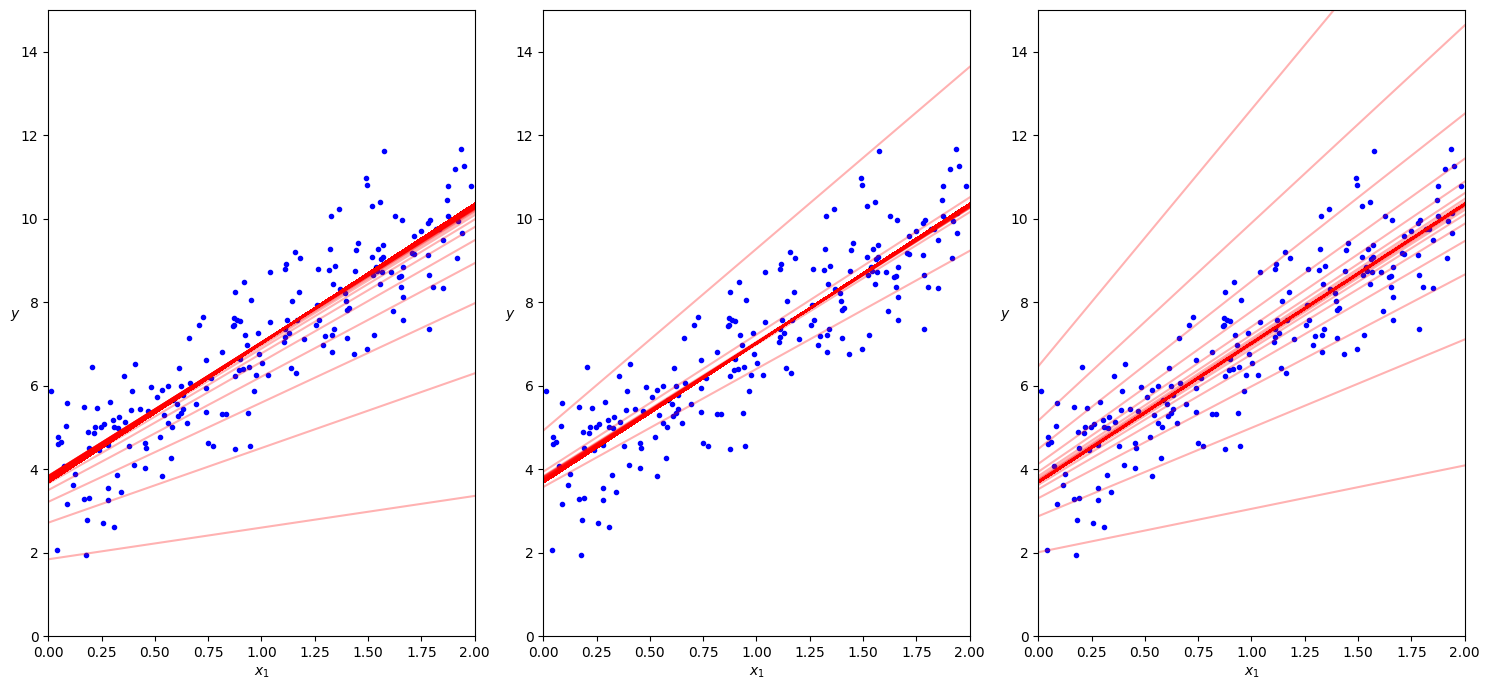

In [ ]:
from sklearn.preprocessing import add_dummy_feature
import matplotlib.pyplot as plt
import numpy as np

# Init
rng = np.random.default_rng(seed=42)
m = 200 # Кол-во шариков
X = 2 * rng.random((m, 1)) 
y = 4 + 3 * X + rng.standard_normal((m, 1)) 
X_b = add_dummy_feature(X)

# Сетка графика 3 строки, 1 столбец
_, axs = plt.subplots(1, 3, figsize=(15, 7))

# eta: learning rate
def batchGradientDescent(axs_i, n_epochs = 1000, eta = 0.1):
	def initDrawPlt():
		axs[axs_i].plot(X, y, "b.")
		axs[axs_i].set_xlabel("$x_1$")
		axs[axs_i].set_ylabel("$y$", rotation=0)
		axs[axs_i].axis([0, 2, 0, 15])
		return axs[axs_i]
	drawPlt = initDrawPlt()
	def addLineToDraw(theta_val, alpha = 0.3):
		line = np.array([[0], [2]])
		drawPlt.plot(line, add_dummy_feature(line) @ theta_val, "r-", alpha=alpha) # alpha типа как opacity

	def findBest():
		m = len(X_b) # number of instances
		rng = np.random.default_rng(seed=42)
		theta = rng.standard_normal((2, 1)) # randomly initialized model parameters
		for epoch in range(n_epochs):
			# 2/m X⊺(X𝛉 − y)
			gradients = 2 / m * X_b.T @ (X_b @ theta - y)
			# 𝛉 − η∇𝛉 MSE(𝛉)
			theta = theta - eta * gradients
			addLineToDraw(theta)
		return theta
	theta = findBest()
	print("best is", theta)

# Тут можно покрутить эпохи и эта чтобы понять, что слишком много эта это плохо
# или хорошо, а также по эпохам понять 
batchGradientDescent(0, n_epochs = 1000, eta = 0.1)
batchGradientDescent(1, n_epochs = 500, eta = 0.3)
batchGradientDescent(2, n_epochs = 500, eta = 0.4)

# Draw
plt.tight_layout()
plt.show()


In [ ]:
# Stochastic Gradient Descent 228
